In [1]:
# ============================================
# Week 04 — Function F1 Bayesian Optimisation
# Retrain surrogate + uncertainty + acquisition
# One-point submission
# ============================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import qmc, norm
from scipy.spatial.distance import cdist

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
# =========================
# 0) CONFIG
# =========================
# Your repo paths (as you described)
INPUTS_PATH = "data/F1/initial_inputs.npy"
OUTPUTS_PATH = "data/F1/initial_outputs.npy"

# If running in an environment like this chat where files may be mounted elsewhere,
# this fallback prevents path errors (safe to keep in your notebook).
if not os.path.exists(INPUTS_PATH) and os.path.exists("/mnt/data/initial_inputs.npy"):
    INPUTS_PATH = "/mnt/data/initial_inputs.npy"
if not os.path.exists(OUTPUTS_PATH) and os.path.exists("/mnt/data/initial_outputs.npy"):
    OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
])

MAXIMIZE = True          # F1 is "find strongest signal" -> treat as maximization
N_CAND = 30000           # candidate points to score
MIN_DIST = 0.04          # keep away from already-sampled points (prevents repeats)
RANDOM_SEED = 123

# Acquisition weighting (explore vs exploit)
W_EXPLORE = 0.7          # weight on uncertainty
W_EXPLOIT = 0.3          # weight on predicted mean

In [3]:
# =========================
# 1) LOAD
# =========================
X = np.load(INPUTS_PATH).astype(float)
y = np.load(OUTPUTS_PATH).astype(float).reshape(-1,)

if X.ndim != 2 or X.shape[1] != 2:
    raise ValueError(f"Expected X shape (n,2). Got {X.shape}")
if y.shape[0] != X.shape[0]:
    raise ValueError(f"X and y size mismatch: {X.shape[0]} vs {y.shape[0]}")

print("\nF1 SHAPE - Inputs:", X.shape, "Outputs:", y.shape)
print("Last values - input:", X[-1:], "output:", y[-1:])


F1 SHAPE - Inputs: (12, 2) Outputs: (12,)
Last values - input: [[0.6458 0.67  ]] output: [-0.00573427]


In [4]:
# =========================
# 2) SURROGATE
# =========================
def fit_gp(X, y, seed=RANDOM_SEED):
    kernel = (
        C(1.0, (1e-6, 1e6))
        * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-3, 1e3), nu=2.5)
        + WhiteKernel(noise_level=1e-8, noise_level_bounds=(1e-12, 1e-1))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=8,
        random_state=seed,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gp.fit(X, y)
    return gp

def fit_rf(X, y, seed=RANDOM_SEED):
    rf = RandomForestRegressor(
        n_estimators=600,
        random_state=seed,
        min_samples_leaf=2,
        n_jobs=-1,
    )
    rf.fit(X, y)
    return rf

def fit_gbm_ensemble(X, y, n_models=15, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    models = []
    for _ in range(n_models):
        s = int(rng.integers(0, 1_000_000))
        m = GradientBoostingRegressor(
            random_state=s,
            n_estimators=400,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
        )
        m.fit(X, y)
        models.append(m)
    return models

gp = fit_gp(X, y)
rf = fit_rf(X, y)
gbm_models = fit_gbm_ensemble(X, y)

print("\nGP kernel after fit:\n", gp.kernel_)




GP kernel after fit:
 0.832**2 * Matern(length_scale=[418, 0.0227], nu=2.5) + WhiteKernel(noise_level=0.1)


In [6]:
# =========================
# 3) UNCERTAINTY
# =========================
def rf_mean_std(rf, Xcand):
    preds = np.vstack([t.predict(Xcand) for t in rf.estimators_])
    return preds.mean(axis=0), preds.std(axis=0, ddof=1)

def gbm_mean_std(models, Xcand):
    preds = np.vstack([m.predict(Xcand) for m in models])
    return preds.mean(axis=0), preds.std(axis=0, ddof=1)

def zscore(a):
    a = np.asarray(a, dtype=float)
    return (a - a.mean()) / (a.std() + 1e-12)



In [7]:
# =========================
# 4) ACQUISITION
#    Composite score = W_EXPLORE*uncertainty + W_EXPLOIT*mean
#    using GP + RF + GBM ensemble agreement.
# =========================
def sample_candidates_sobol(n=N_CAND, bounds=BOUNDS, seed=RANDOM_SEED):
    d = bounds.shape[0]
    # Sobol wants power-of-two for best balance; sample next power-of-two then slice.
    m = int(np.ceil(np.log2(n)))
    n_pow2 = 2 ** m
    sampler = qmc.Sobol(d=d, scramble=True, seed=seed)
    U = sampler.random(n_pow2)
    Xs = qmc.scale(U, bounds[:, 0], bounds[:, 1])
    return Xs[:n]

Xcand = sample_candidates_sobol()

# Distance filter (don’t propose a point too close to existing samples)
min_d = cdist(Xcand, X).min(axis=1)
mask = min_d >= MIN_DIST
if mask.sum() == 0:
    raise RuntimeError("MIN_DIST too large: no candidates remain. Reduce MIN_DIST.")

# Predictions
mu_gp, sd_gp = gp.predict(Xcand, return_std=True)
mu_rf, sd_rf = rf_mean_std(rf, Xcand)
mu_gbm, sd_gbm = gbm_mean_std(gbm_models, Xcand)

# Combine (standardize first so scales don’t dominate)
mu_combo  = (zscore(mu_gp)  + zscore(mu_rf)  + zscore(mu_gbm)) / 3.0
unc_combo = (zscore(sd_gp)  + zscore(sd_rf)  + zscore(sd_gbm)) / 3.0

score = W_EXPLORE * unc_combo + W_EXPLOIT * mu_combo

# Pick best candidate under distance constraint
score_masked = np.where(mask, score, -np.inf)
best_idx = int(np.argmax(score_masked))
x_submit = Xcand[best_idx]


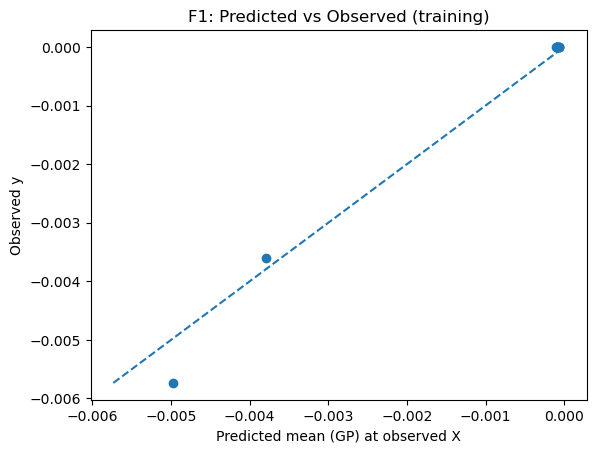

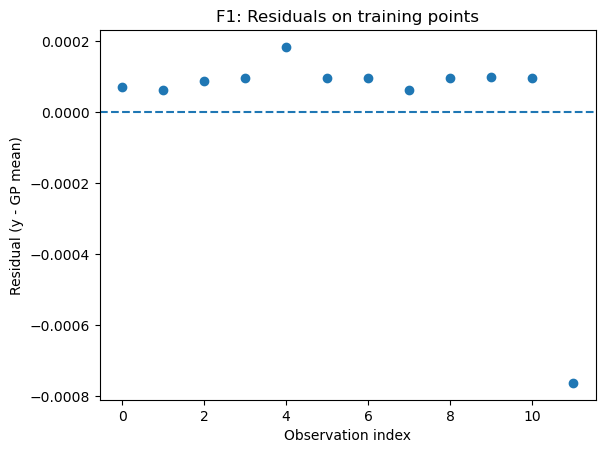

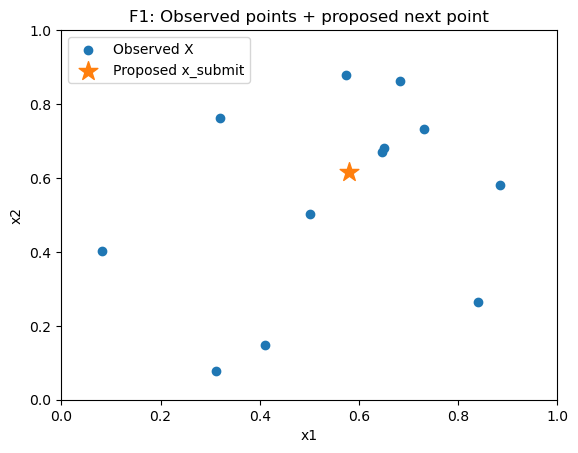

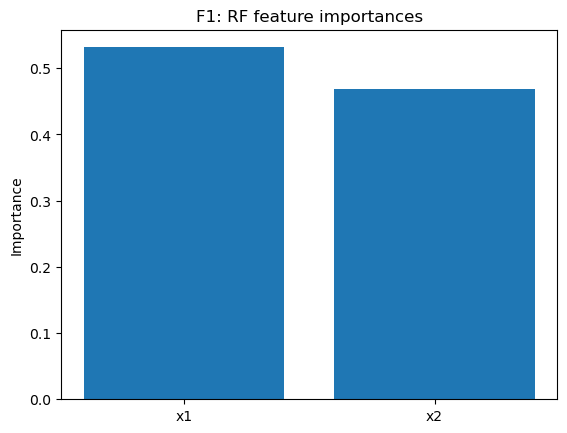


Nearest distance from x_submit to existing samples: 0.08601011479062412


In [8]:
# =========================
# 5) DIAGNOSTICS
# =========================

# 5a) Predicted mean vs observed (GP on training points)
mu_train = gp.predict(X)
plt.figure()
plt.scatter(mu_train, y)
plt.xlabel("Predicted mean (GP) at observed X")
plt.ylabel("Observed y")
plt.title("F1: Predicted vs Observed (training)")
# 45-degree line
mn = min(mu_train.min(), y.min())
mx = max(mu_train.max(), y.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.show()

# 5b) Residuals
resid = y - mu_train
plt.figure()
plt.scatter(np.arange(len(resid)), resid)
plt.xlabel("Observation index")
plt.ylabel("Residual (y - GP mean)")
plt.title("F1: Residuals on training points")
plt.axhline(0, linestyle="--")
plt.show()

# 5c) Where are we sampling? (existing + proposed)
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label="Observed X")
plt.scatter([x_submit[0]], [x_submit[1]], marker="*", s=200, label="Proposed x_submit")
plt.xlim(BOUNDS[0])
plt.ylim(BOUNDS[1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F1: Observed points + proposed next point")
plt.legend()
plt.show()

# 5d) RF feature importances (rough interpretability)
plt.figure()
plt.bar(["x1", "x2"], rf.feature_importances_)
plt.title("F1: RF feature importances")
plt.ylabel("Importance")
plt.show()

# 5e) Quick “not stuck” check: nearest distance to old samples
print("\nNearest distance from x_submit to existing samples:", float(min_d[best_idx]))



In [9]:
# =========================
# 6) OUTPUT (ONE ROW)
# =========================
print("\n=== RECOMMENDED NEXT X (submit this 1 row) ===")
print(x_submit)
print("Rounded (6 dp):", np.round(x_submit, 6))

# Optional: save to a tiny file if your workflow needs it
# np.save("data/F1/week04_x_submit.npy", x_submit)



=== RECOMMENDED NEXT X (submit this 1 row) ===
[0.57922853 0.61553919]
Rounded (6 dp): [0.579229 0.615539]
